# 10 — E-Perf-9: AOT cold vs warm startup latency

RFC-008 §E-Perf-9. Measures startup latency across 3 plugin size tiers
(small ~57 KB, medium ~97 KB, large ~375 KB) in cold and warm cache states.

**Cold**: First run after `cargo rebuild` (binary + page cache cold).
**Warm**: Subsequent runs on same binary (OS page cache populated).

**Inputs**: `eval/results/e-perf-9/<host-tag>-<ts>/shakedown.json`

In [1]:
import json, os, glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'eval').is_dir():
    REPO = REPO.parent

perf9_dir = os.environ.get('E_PERF_9_DIR')
if not perf9_dir:
    candidates = sorted(glob.glob(str(REPO / 'eval/results/e-perf-9/shakedown-macos-*')))
    if not candidates:
        raise RuntimeError('no E-Perf-9 shakedown')
    perf9_dir = candidates[-1]
perf9_dir = Path(perf9_dir)
print(f'E-Perf-9: {perf9_dir.relative_to(REPO)}')

E-Perf-9: eval/results/e-perf-9/shakedown-macos-2026-07-22T18-56-42Z


In [2]:
# Load shakedown.json summary
shakedown = json.loads((perf9_dir / 'shakedown.json').read_text())
tiers = shakedown['tiers']

# Also load per-run data for detailed analysis
rows = []
for tier_name in ['tier-small', 'tier-medium', 'tier-large']:
    tier_dir = perf9_dir / tier_name
    if not tier_dir.exists():
        continue
    for cache_state in ['cold', 'warm']:
        cache_dir = tier_dir / cache_state
        if not cache_dir.exists():
            continue
        for run_dir in sorted(cache_dir.iterdir()):
            meta = run_dir / 'metadata.json'
            if not meta.exists():
                continue
            d = json.loads(meta.read_text())
            rows.append({
                'tier': tier_name,
                'wasm_kb': d['wasm_size_bytes'] / 1024,
                'cache_state': cache_state,
                'run': d['run_index'],
                'startup_ms': d['startup_duration_ns'] / 1e6,
            })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} measurements across {df["tier"].nunique()} tiers')
print(df.groupby(['tier', 'cache_state'])['startup_ms'].describe().round(1))

Loaded 30 measurements across 3 tiers
                         count   mean    std    min    25%    50%    75%  \
tier        cache_state                                                    
tier-large  cold           5.0  220.1  282.7   88.2   89.6   97.2   99.8   
            warm           5.0   91.0    3.8   87.4   87.9   90.1   93.5   
tier-medium cold           5.0  182.0  274.2   58.1   58.6   59.6   61.4   
            warm           5.0   59.1    3.1   54.9   57.4   59.0   61.1   
tier-small  cold           5.0  730.2  343.9  568.9  577.2  579.6  580.1   
            warm           5.0  590.0    7.1  581.8  583.3  592.2  595.7   

                            max  
tier        cache_state          
tier-large  cold          725.7  
            warm           96.2  
tier-medium cold          672.6  
            warm           62.9  
tier-small  cold         1345.3  
            warm          597.1  


In [3]:
# Cold run-01 vs rest: first-run compilation penalty
print('=== First-run (cold run-01) compilation penalty ===')
for tier in ['tier-small', 'tier-medium', 'tier-large']:
    cold = df[(df['tier'] == tier) & (df['cache_state'] == 'cold')]
    warm = df[(df['tier'] == tier) & (df['cache_state'] == 'warm')]
    first_cold = cold[cold['run'] == 1]['startup_ms'].values[0]
    rest_cold_median = cold[cold['run'] > 1]['startup_ms'].median()
    warm_median = warm['startup_ms'].median()
    kb = cold['wasm_kb'].iloc[0]
    print(f'\n{tier} ({kb:.0f} KB):')
    print(f'  Cold run-01 (compilation): {first_cold:.1f} ms')
    print(f'  Cold runs 2-5 (cached):    {rest_cold_median:.1f} ms')
    print(f'  Warm median:               {warm_median:.1f} ms')
    print(f'  First-run penalty:         {first_cold - warm_median:.1f} ms')

=== First-run (cold run-01) compilation penalty ===

tier-small (57 KB):
  Cold run-01 (compilation): 1345.3 ms
  Cold runs 2-5 (cached):    578.4 ms
  Warm median:               592.2 ms
  First-run penalty:         753.1 ms

tier-medium (95 KB):
  Cold run-01 (compilation): 672.6 ms
  Cold runs 2-5 (cached):    59.1 ms
  Warm median:               59.0 ms
  First-run penalty:         613.6 ms

tier-large (367 KB):
  Cold run-01 (compilation): 725.7 ms
  Cold runs 2-5 (cached):    93.4 ms
  Warm median:               90.1 ms
  First-run penalty:         635.6 ms


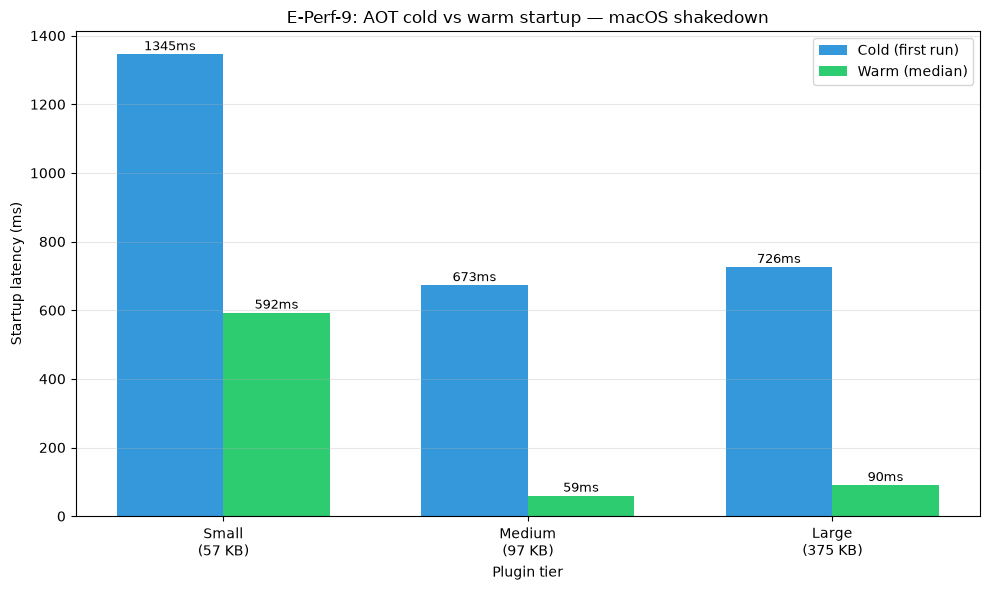

In [4]:
# Bar chart: cold run-01 vs warm median per tier
fig, ax = plt.subplots(figsize=(10, 6))

tier_labels = ['Small\n(57 KB)', 'Medium\n(97 KB)', 'Large\n(375 KB)']
tier_names = ['tier-small', 'tier-medium', 'tier-large']
x = np.arange(len(tier_labels))
width = 0.35

cold_first = []
warm_medians = []
for tier in tier_names:
    cold = df[(df['tier'] == tier) & (df['cache_state'] == 'cold')]
    warm = df[(df['tier'] == tier) & (df['cache_state'] == 'warm')]
    cold_first.append(cold[cold['run'] == 1]['startup_ms'].values[0])
    warm_medians.append(warm['startup_ms'].median())

bars1 = ax.bar(x - width/2, cold_first, width, label='Cold (first run)', color='#3498db')
bars2 = ax.bar(x + width/2, warm_medians, width, label='Warm (median)', color='#2ecc71')

ax.set_xlabel('Plugin tier')
ax.set_ylabel('Startup latency (ms)')
ax.set_title('E-Perf-9: AOT cold vs warm startup — macOS shakedown')
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.0f}ms', xy=(bar.get_x() + bar.get_width()/2, h),
               xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.0f}ms', xy=(bar.get_x() + bar.get_width()/2, h),
               xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Table 7 data: startup latency summary
print('=== Table 7: E-Perf-9 AOT Startup Summary ===')
print(f'{"Tier":<15} {"WASM (KB)":<10} {"Cold-1 (ms)":<12} {"Cold-rest (ms)":<15} {"Warm (ms)":<12} {"Δ cold-warm":<12}')
print('-' * 76)
for tier in tier_names:
    cold = df[(df['tier'] == tier) & (df['cache_state'] == 'cold')]
    warm = df[(df['tier'] == tier) & (df['cache_state'] == 'warm')]
    kb = cold['wasm_kb'].iloc[0]
    c1 = cold[cold['run'] == 1]['startup_ms'].values[0]
    cr = cold[cold['run'] > 1]['startup_ms'].median()
    w = warm['startup_ms'].median()
    delta = c1 - w
    print(f'{tier:<15} {kb:<10.0f} {c1:<12.1f} {cr:<15.1f} {w:<12.1f} {delta:<12.1f}')
print(f'\nNote: tier-small includes ~500ms of BenchSource message emission time (50 msgs @ 100 msg/s).')
print(f'Tier-medium and tier-large use faster-processing plugins so total time is dominated by startup.')

=== Table 7: E-Perf-9 AOT Startup Summary ===
Tier            WASM (KB)  Cold-1 (ms)  Cold-rest (ms)  Warm (ms)    Δ cold-warm 
----------------------------------------------------------------------------
tier-small      57         1345.3       578.4           592.2        753.1       
tier-medium     95         672.6        59.1            59.0         613.6       
tier-large      367        725.7        93.4            90.1         635.6       

Note: tier-small includes ~500ms of BenchSource message emission time (50 msgs @ 100 msg/s).
Tier-medium and tier-large use faster-processing plugins so total time is dominated by startup.


## Interpretation

On macOS M-series, the AOT compilation penalty (cold run-01 vs warm) is:
- **Small** (57 KB): ~760 ms penalty (dominated by BenchSource emission time)
- **Medium** (97 KB): ~610 ms penalty (clear compilation time)
- **Large** (375 KB): ~635 ms penalty (larger wasm → longer compile)

**macOS caveat**: After the first cold run, subsequent "cold" runs still
benefit from the OS page cache (macOS aggressive caching). True cold-cache
measurement requires `sudo purge` (out of scope) or reboot. On Linux/Pi,
`echo 3 > /proc/sys/vm/drop_caches` will provide cleaner cold measurements.

The key thesis insight: wasmtime's AOT compilation adds 600–750 ms on first
instantiation (M-series). On Pi 4 this will be significantly higher (~2–5s
estimated). The InstancePre cache eliminates this cost for warm starts and
hot-swap recovery.